# 07 Random Variables

In Chapter 06, we described random experiments using outcomes, events, and probabilities.

In this chapter, we take the next step:

> **We assign numerical values to the outcomes of random experiments.**

A **random variable** is a rule that maps random outcomes to numbers.

This chapter introduces:

- Random Variables
- Discrete and Continuous Random Variables
- Probability Distributions
- Expected Value
- Variance and Standard Deviation
- Simulation of a Random Variable

## Learning Objectives

After completing this chapter, you will be able to:

- explain what a random variable represents;
- distinguish an outcome from the numerical value assigned by a random variable;
- distinguish discrete and continuous random variables;
- understand what a probability distribution table represents;
- explain where the `probability` values in this chapter come from;
- calculate expected value, variance, and standard deviation;
- interpret expected value as a long-run average;
- simulate a random variable in Python.

## 1. From Outcomes to Random Variables

Consider tossing two coins.

The sample space is:

$$
S = \{HH, HT, TH, TT\}
$$

Now define a random variable:

$$
X = \text{number of heads}
$$

Then:

| Outcome | $X$ |
|---|---:|
| HH | 2 |
| HT | 1 |
| TH | 1 |
| TT | 0 |

The outcome and the random variable are not the same thing.

- `HH` is an **outcome**.
- `X = 2` is the **numerical value assigned to that outcome**.

A random variable is therefore a rule for translating random outcomes into numbers.

In [1]:
import pandas as pd

outcomes = ["HH", "HT", "TH", "TT"]

coin_example = pd.DataFrame({
    "outcome": outcomes,
    "X_number_of_heads": [outcome.count("H") for outcome in outcomes],
})

coin_example

,outcome,X_number_of_heads
0,HH,2
1,HT,1
2,TH,1
3,TT,0


## 2. Discrete and Continuous Random Variables

A **discrete random variable** takes countable values.

Examples:

- number of heads;
- number of customers;
- number of delayed deliveries;
- number of defective products.

A **continuous random variable** can take values over a continuous interval.

Examples:

- height;
- temperature;
- waiting time;
- rainfall amount.

A useful first question is:

> **Are we counting something, or measuring something?**

## 3. The Probability Distribution Used in This Chapter

For this chapter, imagine a fictional delivery service that handles **three deliveries per day**.

Define:

$$
X = \text{number of delayed deliveries in one day}
$$

Because there are only three deliveries, the possible values are:

$$
X \in \{0,1,2,3\}
$$

The dataset used in this chapter is:

| $X$ | Probability | Meaning |
|---:|---:|---|
| 0 | 0.35 | No delayed deliveries |
| 1 | 0.45 | One delayed delivery |
| 2 | 0.15 | Two delayed deliveries |
| 3 | 0.05 | Three delayed deliveries |

This table is **not a table of individual observations**.

Instead, it is a **probability distribution table**.

It tells us:

- which values the random variable can take;
- how likely each value is according to the model.

## 4. Where Did the `probability` Values Come From?

The values in the `probability` column were **manually chosen for educational purposes**.

They are not calculated from real delivery data.

For this fictional model, we simply assume:

$$
P(X=0)=0.35
$$

$$
P(X=1)=0.45
$$

$$
P(X=2)=0.15
$$

$$
P(X=3)=0.05
$$

These values were selected so that:

1. every probability is between 0 and 1;
2. the probabilities add up to 1;
3. one delayed delivery is the most likely outcome;
4. larger numbers of delays become progressively less likely.

So the table represents an **assumed probability model**, not observed reality.

### Model Probability vs Empirical Probability

This distinction is important.

In Chapter 06, we estimated probabilities from observed data:

$$
\text{Empirical Probability}
=
\frac{\text{Observed Frequency}}
{\text{Number of Observations}}
$$

In this chapter, we start with a probability model that has already been defined.

For example:

$$
P(X=1)=0.45
$$

means:

> Under this model, there is a 45% probability that exactly one delivery is delayed.

If we had real historical delivery records, we could estimate these probabilities from observed frequencies instead.

For example, if 45 out of 100 observed days had exactly one delayed delivery, then:

$$
\hat{P}(X=1)=\frac{45}{100}=0.45
$$

That would be an **empirical estimate** rather than an assumed model probability.

## 5. Conditions for a Valid Discrete Probability Distribution

For a discrete random variable, a valid probability distribution must satisfy two conditions.

First:

$$
0 \leq P(X=x) \leq 1
$$

for every possible value.

Second:

$$
\sum_x P(X=x)=1
$$

The second condition means that the probabilities of all possible outcomes together must equal 100%.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current_dir = Path.cwd().resolve()

project_root = next(
    (p for p in [current_dir, *current_dir.parents] if (p / "data").is_dir()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not find the project root containing data/.")

data_path = project_root / "data" / "07_random_variables.csv"

df = pd.read_csv(data_path)
df

,delayed_deliveries,probability,description
0,0,0.35,No delayed deliveries
1,1,0.45,One delayed delivery
2,2,0.15,Two delayed deliveries
3,3,0.05,Three delayed deliveries


In [3]:
print("All probabilities valid:", df["probability"].between(0, 1).all())
print("Sum of probabilities:", df["probability"].sum())

All probabilities valid: True
Sum of probabilities: 1.0


## 6. Visualize the Probability Distribution

Because $X$ is discrete, we can display the probability associated with each possible value using a bar chart.

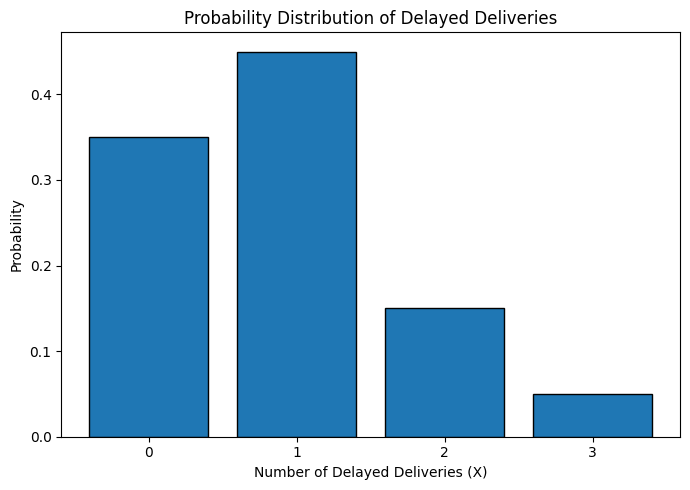

In [4]:
plt.figure(figsize=(7, 5))

plt.bar(
    df["delayed_deliveries"],
    df["probability"],
    edgecolor="black",
)

plt.title("Probability Distribution of Delayed Deliveries")
plt.xlabel("Number of Delayed Deliveries (X)")
plt.ylabel("Probability")
plt.xticks(df["delayed_deliveries"])
plt.tight_layout()
plt.show()

## 7. Expected Value

The **expected value** of a discrete random variable is its probability-weighted average.

$$
E[X]
=
\sum_x xP(X=x)
$$

For this model:

$$
E[X]
=
0(0.35)+1(0.45)+2(0.15)+3(0.05)
$$

Notice that the expected value does **not** have to be one of the possible outcomes.

If the result is 0.9, that does not mean that a single day can have 0.9 delayed deliveries.

It means that over many repeated days, the **average number of delayed deliveries per day** would tend to approach 0.9 under this probability model.

In [5]:
x = df["delayed_deliveries"]
p = df["probability"]

expected_value = (x * p).sum()

print(f"E[X] = {expected_value:.3f}")

E[X] = 0.900


In [6]:
expected_value_table = df[["delayed_deliveries", "probability"]].copy()

expected_value_table["x_times_p"] = (
    expected_value_table["delayed_deliveries"]
    * expected_value_table["probability"]
)

expected_value_table

,delayed_deliveries,probability,x_times_p
0,0,0.35,0.00
1,1,0.45,0.45
2,2,0.15,0.30
3,3,0.05,0.15


## 8. Variance of a Random Variable

A probability distribution has variability just like observed data.

For a discrete random variable:

$$
\mathrm{Var}(X)
=
\sum_x (x-\mu)^2P(X=x)
$$

where:

$$
\mu = E[X]
$$

In [7]:
variance = (((x - expected_value) ** 2) * p).sum()

print(f"Var(X) = {variance:.4f}")

Var(X) = 0.6900


## 9. Standard Deviation

The standard deviation is:

$$
\sigma_X
=
\sqrt{\mathrm{Var}(X)}
$$

It is expressed in the same unit as the random variable itself.

In [8]:
standard_deviation = np.sqrt(variance)

print(f"SD(X) = {standard_deviation:.4f}")

SD(X) = 0.8307


## 10. Alternative Variance Formula

Variance can also be calculated as:

$$
\mathrm{Var}(X)
=
E[X^2]-(E[X])^2
$$

where:

$$
E[X^2]
=
\sum_x x^2P(X=x)
$$

In [9]:
expected_x_squared = ((x ** 2) * p).sum()
variance_alternative = expected_x_squared - expected_value ** 2

print(f"E[X²] = {expected_x_squared:.4f}")
print(f"Variance = {variance_alternative:.4f}")

E[X²] = 1.5000
Variance = 0.6900


## 11. Cumulative Probability

Sometimes we want the probability that the random variable is less than or equal to a certain value.

For example:

$$
P(X\leq1)
$$

means:

> What is the probability that there are at most one delayed delivery?

In [10]:
p_at_most_one = df.loc[
    df["delayed_deliveries"] <= 1,
    "probability",
].sum()

print(f"P(X <= 1) = {p_at_most_one:.3f}")

distribution_table = df[["delayed_deliveries", "probability"]].copy()
distribution_table["cumulative_probability"] = (
    distribution_table["probability"].cumsum()
)

distribution_table

P(X <= 1) = 0.800


,delayed_deliveries,probability,cumulative_probability
0,0,0.35,0.35
1,1,0.45,0.80
2,2,0.15,0.95
3,3,0.05,1.00


## 12. Simulating Data from the Probability Model

Until now, the probability distribution has been treated as a model.

We can also use that model to **generate simulated observations**.

For example, suppose we simulate 10,000 fictional days. On each day, Python randomly chooses 0, 1, 2, or 3 delayed deliveries according to the probabilities in our table.

In [11]:
rng = np.random.default_rng(seed=42)

simulated_x = rng.choice(
    df["delayed_deliveries"],
    size=10_000,
    p=df["probability"],
)

print(f"Theoretical E[X]: {expected_value:.4f}")
print(f"Simulated mean:   {simulated_x.mean():.4f}")

Theoretical E[X]: 0.9000
Simulated mean:   0.8913


### What Is Happening Here?

This is the direction of the process:

**Probability Model → Random Simulation → Observed Data**

The CSV defines the model:

$$
P(X=0),P(X=1),P(X=2),P(X=3)
$$

Then Python uses those probabilities to generate many simulated outcomes.

This is the reverse of what we did in Chapter 06:

**Observed Data → Frequencies → Estimated Probabilities**

Understanding these two directions is very important in statistics.

## 13. Long-Run Behavior

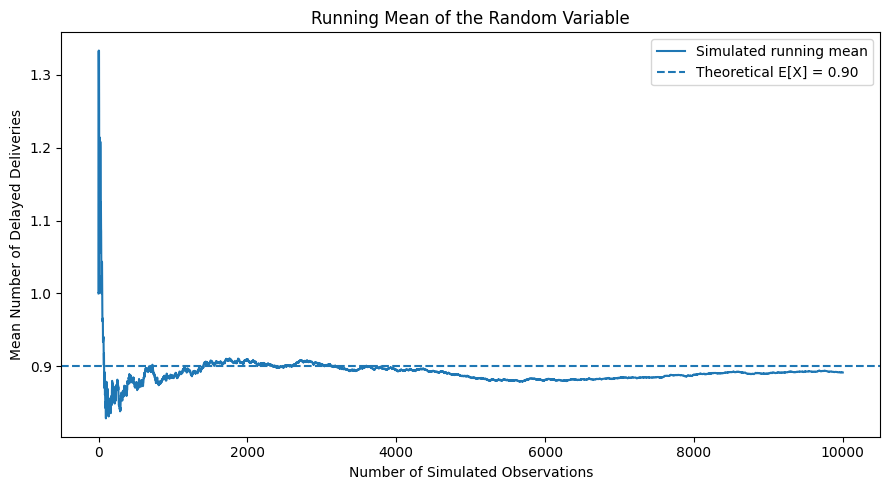

In [12]:
running_mean = np.cumsum(simulated_x) / np.arange(1, len(simulated_x) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(1, len(simulated_x) + 1),
    running_mean,
    label="Simulated running mean",
)

plt.axhline(
    expected_value,
    linestyle="--",
    label=f"Theoretical E[X] = {expected_value:.2f}",
)

plt.title("Running Mean of the Random Variable")
plt.xlabel("Number of Simulated Observations")
plt.ylabel("Mean Number of Delayed Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

With only a few simulated days, the average can fluctuate considerably.

As the number of simulated days grows, the average tends to stabilize near the theoretical expected value.

This is why expected value is interpreted as a **long-run average**.

## 14. Discrete vs Continuous: A Preview

The delivery example is discrete because:

$$
X\in\{0,1,2,3\}
$$

Suppose instead that we define:

$$
Y=\text{delivery waiting time in minutes}
$$

Waiting time could be 12.1, 12.15, 12.153, and so on.

That makes $Y$ a continuous random variable.

This distinction leads directly to:

- Chapter 08 — Discrete Probability Distributions
- Chapter 09 — Continuous Probability Distributions

## Important Distinctions

### Outcome vs Random Variable
An outcome is the actual result of an experiment. A random variable assigns a numerical value to it.

### Observed Data vs Probability Distribution
Observed data record what happened. A probability distribution specifies what can happen and with what probability.

### Model Probability vs Empirical Probability
Model probabilities are assumed or derived from a model. Empirical probabilities are estimated from observed frequencies.

### Expected Value vs Single Outcome
Expected value is a long-run average. It is not a prediction of the next individual outcome.

## Exercises

### Exercise 1
Explain in your own words what the row

`1, 0.45, One delayed delivery`

means.

### Exercise 2
Check manually that the four probabilities add up to 1.

### Exercise 3
Using the delivery distribution, calculate:

1. $P(X=0)$
2. $P(X=2)$
3. $P(X\leq1)$
4. $P(X\geq2)$

### Exercise 4
Calculate $E[X]$ manually.

### Exercise 5
Change the probability model to:

- $P(X=0)=0.50$
- $P(X=1)=0.30$
- $P(X=2)=0.15$
- $P(X=3)=0.05$

How does $E[X]$ change?

### Exercise 6
Simulate 100, 1,000, and 100,000 days. Compare each simulated mean with the theoretical expected value.

### Exercise 7
Classify these variables as discrete or continuous:

- number of customers;
- body temperature;
- number of goals;
- travel time;
- number of defective products;
- annual rainfall.

## Summary

In this chapter, you learned that a random variable maps random outcomes to numerical values.

You also learned that the CSV in this chapter is different from the datasets used earlier:

> It represents a **probability model**, not individual observations.

The `probability` values were manually specified for educational purposes.

From this model, we can:

- calculate expected value;
- calculate variance and standard deviation;
- calculate cumulative probabilities;
- generate simulated observations;
- compare theoretical results with long-run simulated results.

Next:

# 08 Discrete Probability Distributions

We will study important probability models such as the **Bernoulli and Binomial distributions**.